<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="https://github.com/kunalsmile/PES_MTech/blob/main/Faculty.png?raw=1">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Session 3) </b><br>
                <font color="#21618C" size=4px>
                    <b> MNIST neural network - Hyperparameter Optimization using Tensorflow</b>
                </font>
            </div>
        </td>
    </tr>
</table>

### MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

In [ ]:
import tensorflow as tf
import numpy as np
# !pip install scikeras

In [ ]:
# un-comment this if executing locally - to download the mnsit dataset
# import requests
# requests.packages.urllib3.disable_warnings()
# import ssl

# try:
#     _create_unverified_https_context = ssl._create_unverified_context
# except AttributeError:
#     # Legacy Python that doesn't verify HTTPS certificates by default
#     pass
# else:
#     # Handle target environment that doesn't support HTTPS verification
#     ssl._create_default_https_context = _create_unverified_https_context

In [ ]:
#Load the MNIST digit datset
from tensorflow.keras.datasets import mnist
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

In [ ]:
xtrain.shape # there are 60000 images of each 28 rows and 28 columns

(60000, 28, 28)

In [ ]:
xtest.shape

(10000, 28, 28)

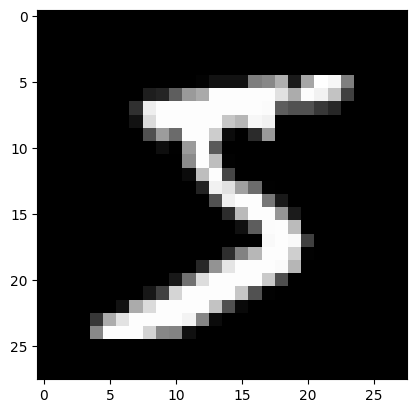

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(xtrain[0,:,:], cmap='gray')
plt.show()

In [ ]:
ytrain[0] # The output label for the image shown above

np.uint8(5)

In [ ]:
x_train=xtrain.reshape(60000,28*28) # reshaping images as one dimensional
x_test=xtest.reshape(10000,28*28)

In [ ]:
x_train=x_train/255. # scaling the images
x_test=x_test/255.

In [ ]:
y_train=tf.keras.utils.to_categorical(ytrain,num_classes=10) # Encoding the target levels
y_test=tf.keras.utils.to_categorical(ytest,num_classes=10)

In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
ytrain[0]

np.uint8(5)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers, optimizers

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

# Define the input shape (assuming MNIST flattened input of 784 features)
input_shape = (784,)

# Define L1-L2 regularization parameters
l1_reg = 0.1
l2_reg = 0.01

# Create the Sequential model
model = Sequential([
    tf.keras.Input(shape=input_shape),
    Dense(units=128, activation='relu', kernel_initializer='he_uniform',
          kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
    Dropout(0.1),
    Dense(units=64, activation='relu', kernel_initializer='he_uniform',
          kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
    Dropout(0.1),
    Dense(units=1, activation='sigmoid') # 1 output neuron with sigmoid activation
])

# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Save the Keras model in HDF5 format
model.save('my_model.h5')
print("Model saved as 'my_model.h5'")

Model saved as 'my_model.h5'


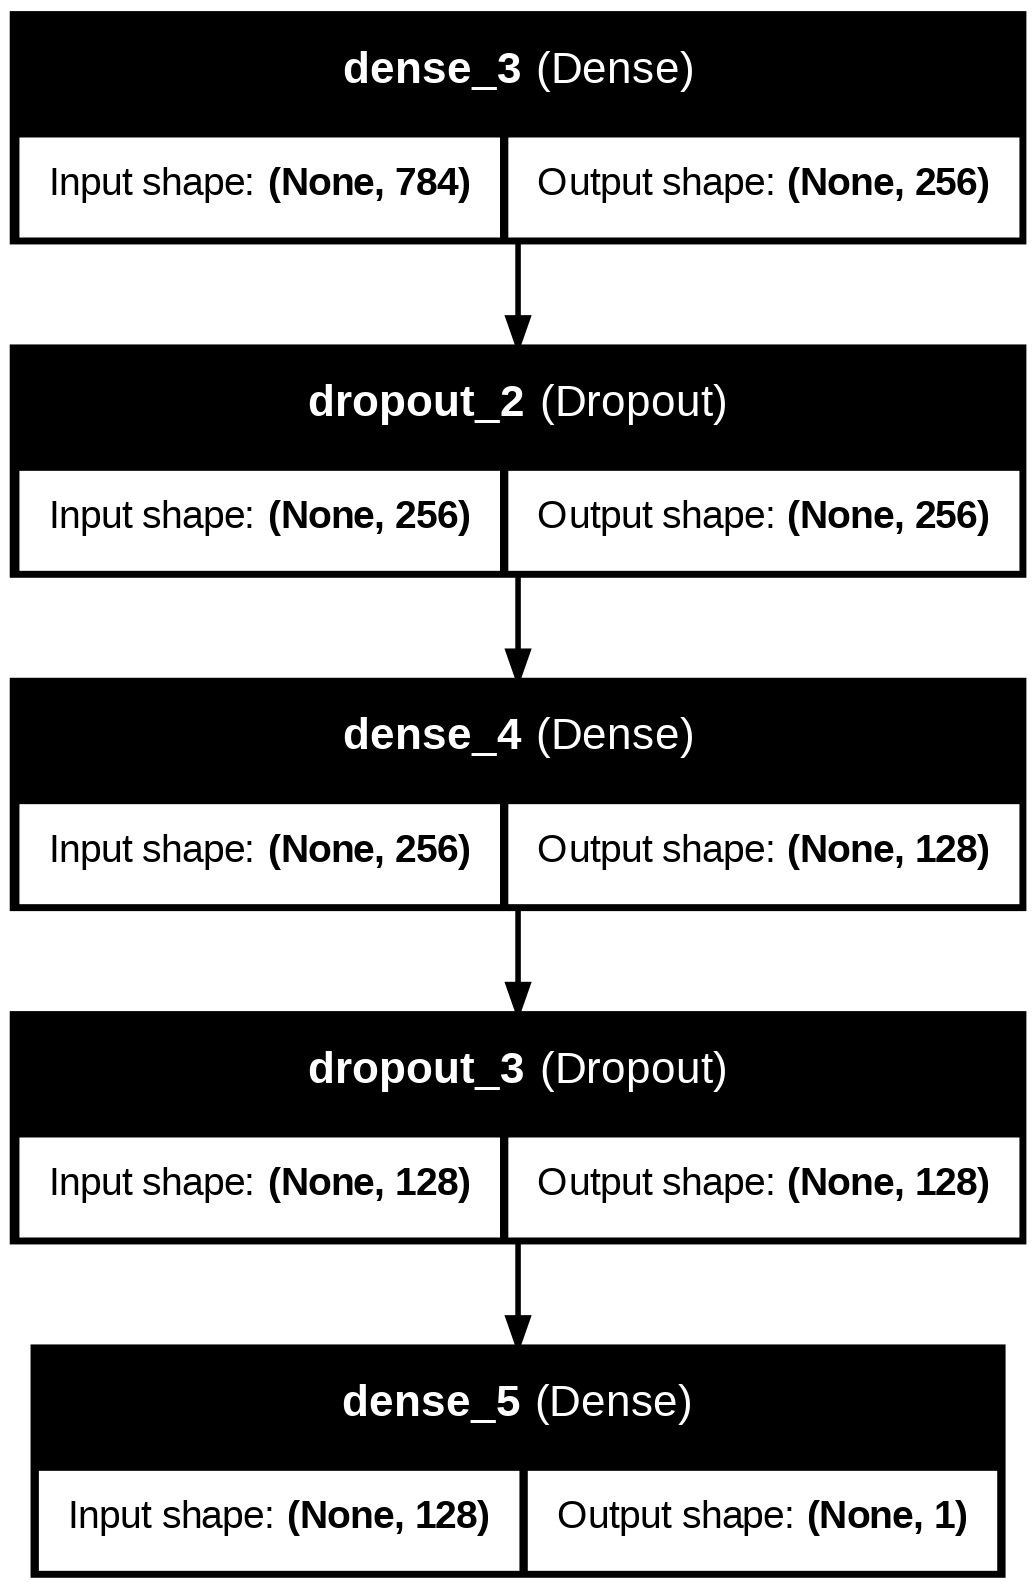

In [3]:
from tensorflow.keras.utils import plot_model

# Plot the model architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the plotted model (this will show the image in the notebook output)
from IPython.display import Image
Image(filename='model_architecture.png')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers, optimizers

#Create the function to define a DNN model with dynamic iteration, learning_rate,
#regularization penalty# neurons in the hidden layer for tuning
def train_and_test_model(itr,learning_rate,lamda):

    iterations=itr
    learning_rate=learning_rate
    hidden_nodes=256
    output_nodes=10

    model=Sequential([
        tf.keras.Input(shape=(784,)), # Use Input layer to define input shape
        Dense(units=hidden_nodes,activation='relu'),
        Dense(units=hidden_nodes,activation='relu'),
        Dense(units=output_nodes,activation='softmax',kernel_regularizer=regularizers.l2(lamda))
    ])

    sgd=optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])

    model.fit(x_train,y_train,epochs=iterations,batch_size=1000,verbose=0)
    [loss,score_train]=model.evaluate(x_train,y_train)
    [loss,score_test]=model.evaluate(x_test,y_test)

    return score_train,score_test  # returning both train and test scores

In [ ]:
learning_rate=0.00001 # Choose very small value of learning rate
lamda=0
train_and_test_model(10,learning_rate,lamda) # Leading to vanishing gradiant problem
# loss is not changing in each iteration much and model accuracy is poor.
#To understand it run with verbose =1 in the above function

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0715 - loss: 2.3644
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0706 - loss: 2.3650


(0.07151667028665543, 0.0706000030040741)

In [ ]:
learning_rate=0.001 # Increasing the learning_rate to 0.001 improving the performance slightly
lamda=0 # no regularization
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5863 - loss: 1.9835
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5961 - loss: 1.9752


(0.5862666964530945, 0.5960999727249146)

In [ ]:
learning_rate=0.1# Increasing the learning_rate to 0.1 improving the performance above 90 percent
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9432 - loss: 0.2001
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9436 - loss: 0.1977


(0.9431833624839783, 0.9435999989509583)

In [ ]:
learning_rate=1.0 # learning rate of 1 giving very good results for this datset [It may not be same for all the data]
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9844 - loss: 0.0532
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0794


(0.9843999743461609, 0.9745000004768372)

In [ ]:
learning_rate=50.0   # Increasing the lr to 50 leading to Exploding Gradient. Loss going out of control
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1022 - loss: 13.8985
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1010 - loss: 13.8418


(0.10218333452939987, 0.10100000351667404)

In [ ]:
learning_rate=0.0000001  # Vanishing Gradient
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1242 - loss: 2.3101
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1241 - loss: 2.3132


(0.12423333525657654, 0.12409999966621399)

In [ ]:
learning_rate=1e-2
lamda=0.02 # Introduce small regularization, regularization will reduce overfitting, but bias error may slightly increase
train_and_test_model(10,learning_rate,lamda) # Less overfitting

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8672 - loss: 0.8781
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 0.8562


(0.8671833276748657, 0.8747000098228455)

In [ ]:
learning_rate=1.0
lamda=1
train_and_test_model(10,learning_rate,lamda) # Underfitting, penalty(lamda) of 1, reducing the performance greatly

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1138 - loss: 26.4874
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1147 - loss: 26.4871


(0.11379999667406082, 0.11469999700784683)

In [ ]:
#Coarse tuning - Explore the model for wide span of learning rate and lamda(regularization penalty)
learning_rate=[0.0001,0.001,0.01,0.1,1,10,20,50]
lam=[0.0001,0.001,0.01,0.1,1,10,20,50]
for i,j in zip(learning_rate,lam):
    score=train_and_test_model(10,i,j)
    print('epocs:',10,'train_accuracy:',score[0],'test_accuracy:',score[1],'alpha:', i,'Regularization:',j)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1311 - loss: 2.2938
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1269 - loss: 2.2944
epocs: 10 train_accuracy: 0.13108333945274353 test_accuracy: 0.12690000236034393 alpha: 0.0001 Regularization: 0.0001
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5646 - loss: 2.0090
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5732 - loss: 2.0013
epocs: 10 train_accuracy: 0.564633309841156 test_accuracy: 0.573199987411499 alpha: 0.001 Regularization: 0.001
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8684 - loss: 0.7340
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8751 - loss: 0.7123
epocs: 10 train_accuracy: 0.8684333562850952 test_accuracy: 0.8751000165939331 alpha: 0.01 Regularization: 0.01
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8976 - loss: 0.5215
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9040 - loss: 0.5043
epocs: 10 train_accuracy: 0.897599995136261 test_a

ValueError: Argument `learning_rate` should be float, or an instance of LearningRateSchedule, or a callable (that takes in the current iteration value and returns the corresponding learning rate value). Received instead: learning_rate=1

In [ ]:
#Another random way of doing coarse tuning
import math
for k in range(1,10):
    learning_rate = math.pow(10, np.random.uniform(-7.0, 3.0))
    Lambda = math.pow(10, np.random.uniform(-7,-2))
    best_acc = train_and_test_model(10, learning_rate, Lambda)
    print('k:',k,'epocs:',100,'accuracy:',best_acc,'alpha:', learning_rate,'Regularization:',Lambda)


In [ ]:
import math
math.pow(10,np.random.uniform(-7.0, 3.0))

In [ ]:
#Create the function to define a DNN model with dynamic learning_rate, regularization penalty
         # neurons in the hidden layer,activation function and weight intitialization for tuning
def tune_model(learning_rate,activation, lamda,initializer,num_unit):
    model = Sequential()
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation, input_dim=784))
    #model.add(Dropout(dropout_rate))
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation))
    #model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax',kernel_regularizer=regularizers.l2(lamda)))
    sgd = optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])
    return model

In [ ]:
#he_normal
#std = sqrt(2/fan_in)
#fan_in= number of neurons in the hiddenlayer

In [ ]:
#Define hyper parameters values
batch_size = [20, 50, 100][:1]
epochs = [1, 20, 50][:1]
initializer = ['lecun_uniform', 'normal', 'he_normal', 'he_uniform'][:1]
learning_rate = [0.1, 0.001, 0.02][:1]
lamda = [0.001, 0.005, 0.01][:1]
num_unit = [256, 128][:1]
activation = ['relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear'][:1]

In [ ]:
#create dictionary with hyper parameters
parameters = dict(batch_size = batch_size,
                  epochs = epochs,
                  learning_rate=learning_rate,
                  lamda = lamda,
                  num_unit = num_unit,
                  initializer = initializer,
                  activation = activation)

In [ ]:
parameters

In [ ]:
# Make this keras model compatible to sklearn to apply gridsearchCV
#model =tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn=tune_model, verbose=0)
from scikeras.wrappers import KerasClassifier
model = KerasClassifier(model = tune_model, verbose=0, activation='relu',initializer='lecun_uniform',
                       lamda=0.001,learning_rate=0.1,num_unit=256)

In [ ]:
from sklearn.model_selection import GridSearchCV
models = GridSearchCV(estimator = model, param_grid=parameters, n_jobs=1)

In [ ]:
best_model = models.fit(x_train, y_train)
print('Best model :',best_model.best_params_)

In [ ]:
import pandas as pd
pd.DataFrame(best_model.cv_results_)

In [ ]:
# Run for all the combinations and take the best results interms of both bias and variance error